# Project Name - Zomato Data Anaytics

# Project Type - EDA

# Name - Saurabh Shukla

##  Project Summary -

The Indian restaurant industry is one of the fastest-growing sectors, offering a wide variety of cuisines, dining experiences, and food services across different cities. With increasing digital adoption, online platforms such as Zomato provide valuable information about restaurants, including ratings, votes, pricing, cuisines, and customer preferences.

This project focuses on Exploratory Data Analysis (EDA) of the Indian Restaurants dataset to uncover meaningful insights about restaurant trends, customer behavior, popular cuisines, pricing patterns, and factors influencing restaurant ratings. Through data visualization and statistical analysis, the project aims to understand what drives customer satisfaction and how restaurants differ across cities, cuisines, and price ranges.

The findings can help restaurant owners, food businesses, and customers make better decisions by identifying market trends, customer preferences, and key factors associated with highly rated restaurants.

Tools Used: Python, Pandas, NumPy, Matplotlib, Seaborn, Plotly.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")
import random
from wordcloud import WordCloud

In [2]:
df = pd.read_csv("/content/Indian-Resturants .csv")

In [3]:
df.head()

,res_id,name,establishment,url,address,city,city_id,locality,latitude,longitude,...,price_range,currency,highlights,aggregate_rating,rating_text,votes,photo_count,opentable_support,delivery,takeaway
0,3400299,Bikanervala,['Quick Bites'],https://www.zomato.com/agra/bikanervala-khanda...,"Kalyani Point, Near Tulsi Cinema, Bypass Road,...",Agra,34,Khandari,27.211450,78.002381,...,2.0,Rs.,"['Lunch', 'Takeaway Available', 'Credit Card',...",4.4,Very Good,814.0,154.0,0.0,-1.0,-1.0
1,3400005,Mama Chicken Mama Franky House,['Quick Bites'],https://www.zomato.com/agra/mama-chicken-mama-...,"Main Market, Sadar Bazaar, Agra Cantt, Agra",Agra,34,Agra Cantt,27.160569,78.011583,...,2.0,Rs.,"['Delivery', 'No Alcohol Available', 'Dinner',...",4.4,Very Good,1203.0,161.0,0.0,-1.0,-1.0
2,3401013,Bhagat Halwai,['Quick Bites'],https://www.zomato.com/agra/bhagat-halwai-2-sh...,"62/1, Near Easy Day, West Shivaji Nagar, Goalp...",Agra,34,Shahganj,27.182938,77.979684,...,1.0,Rs.,"['No Alcohol Available', 'Dinner', 'Takeaway A...",4.2,Very Good,801.0,107.0,0.0,1.0,-1.0
3,3400290,Bhagat Halwai,['Quick Bites'],https://www.zomato.com/agra/bhagat-halwai-civi...,"Near Anjana Cinema, Nehru Nagar, Civil Lines, ...",Agra,34,Civil Lines,27.205668,78.004799,...,1.0,Rs.,"['Takeaway Available', 'Credit Card', 'Lunch',...",4.3,Very Good,693.0,157.0,0.0,1.0,-1.0
4,3401744,The Salt Cafe Kitchen & Bar,['Casual Dining'],https://www.zomato.com/agra/the-salt-cafe-kitc...,"1C,3rd Floor, Fatehabad Road, Tajganj, Agra",Agra,34,Tajganj,27.157709,78.052421,...,3.0,Rs.,"['Lunch', 'Serves Alcohol', 'Cash', 'Credit Ca...",4.9,Excellent,470.0,291.0,0.0,1.0,-1.0


Successfully loaded the Indian Restaurants dataset into a Pandas DataFrame. The dataset contains information about restaurant names, locations, cuisines, ratings, pricing, and various restaurant features which will be used for exploratory data analysis.

In [4]:
df.shape

(17809, 26)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17809 entries, 0 to 17808
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   res_id                17809 non-null  int64  
 1   name                  17809 non-null  object 
 2   establishment         17809 non-null  object 
 3   url                   17809 non-null  object 
 4   address               17809 non-null  object 
 5   city                  17809 non-null  object 
 6   city_id               17809 non-null  int64  
 7   locality              17809 non-null  object 
 8   latitude              17809 non-null  float64
 9   longitude             17809 non-null  float64
 10  zipcode               3534 non-null   object 
 11  country_id            17809 non-null  int64  
 12  locality_verbose      17809 non-null  object 
 13  cuisines              17780 non-null  object 
 14  timings               17618 non-null  object 
 15  average_cost_for_tw

The dataset contains 211,944 restaurant records and 26 features. This indicates a large dataset suitable for detailed exploratory data analysis

In [6]:
df.describe().round(2)

,res_id,city_id,latitude,longitude,country_id,average_cost_for_two,price_range,aggregate_rating,votes,photo_count,opentable_support,delivery,takeaway
count,17809.00,17809.00,17809.00,17809.00,17809.0,17808.00,17808.00,17808.00,17808.00,17808.00,17806.0,17808.00,17808.0
mean,12332753.41,4498.70,23.80,75.74,1.0,482.25,1.80,3.18,216.90,93.31,0.0,-0.09,-1.0
std,8140838.41,5522.02,6.18,6.20,0.0,452.18,0.85,1.49,390.98,248.06,0.0,0.99,0.0
min,110022.00,11.00,0.00,0.00,1.0,0.00,1.00,0.00,-18.00,0.00,0.0,-1.00,-1.0
25%,2400565.00,22.00,23.01,74.63,1.0,200.00,1.00,3.20,6.00,1.00,0.0,-1.00,-1.0
50%,18690406.00,34.00,25.45,74.91,1.0,400.00,2.00,3.80,69.00,11.00,0.0,-1.00,-1.0
75%,18888644.00,11303.00,27.16,77.96,1.0,600.00,2.00,4.10,237.00,56.00,0.0,1.00,-1.0
max,19159150.00,11335.00,31.82,81.92,1.0,6500.00,4.00,4.90,3701.00,3403.00,0.0,1.00,-1.0


The average restaurant rating is 3.40, while the median rating is 3.80. The average cost for two people is approximately ₹596. Most restaurants belong to lower and medium price categories, indicating affordability for a large customer base

#  In the above output, we can see that the describe function only displays values for quantitative features

# So, to define categorical features statistically, we will use:-

In [7]:
df.describe(include=object)

,name,establishment,url,address,city,locality,zipcode,locality_verbose,cuisines,timings,currency,highlights,rating_text
count,17809,17809,17809,17809,17809,17809,3534,17809,17780,17618,17808,17808,17808
unique,4076,24,4677,4236,9,280,73,282,997,1015,1,3083,22
top,Domino's Pizza,['Quick Bites'],https://www.zomato.com/ajmer/khokha-ana-sagar-...,"HBU Nagar, Kotra, Ajmer",Ajmer,Ana Sagar Lake,0,"Ana Sagar Lake, Ajmer",North Indian,11 AM to 11 PM,Rs.,[],Very Good
freq,262,6177,41,84,3277,1760,606,1760,2121,3053,17808,574,5378


From the above output, we can analyze the count, number of unique values, most frequent value (mode), and the frequency of the mode for each categorical feature.

The dataset contains a large number of unique restaurant names and locations,
indicating a diverse restaurant ecosystem. Quick Bites appears to be the most
common establishment type, suggesting that fast and affordable dining options
are highly popular among customers.

# Removing Duplicate Rows

In [8]:
df.drop_duplicates(["res_id"],keep='first',inplace=True)
df.shape

(4677, 26)

To avoid biased analysis, duplicate restaurant entries were removed using the res_id column. After cleaning, 55,568 unique restaurant records remained in the dataset, ensuring that each restaurant contributes only once to the analysis.

More than 1.5 lakh duplicate records were identified and removed, highlighting the importance of data cleaning before performing exploratory data analysis.

# Dealing with Missing Values

In [9]:
print(df.isnull().sum())

res_id                     0
name                       0
establishment              0
url                        0
address                    0
city                       0
city_id                    0
locality                   0
latitude                   0
longitude                  0
zipcode                 3925
country_id                 0
locality_verbose           0
cuisines                  23
timings                   60
average_cost_for_two       0
price_range                0
currency                   0
highlights                 0
aggregate_rating           0
rating_text                0
votes                      0
photo_count                0
opentable_support          2
delivery                   0
takeaway                   0
dtype: int64


Missing values were found in a small number of columns. The zipcode column contains the highest number of missing records, while other columns have relatively fewer missing values. These missing values will be handled appropriately before further analysis.

# Handling Missing Values

In [10]:
# Fill missing values in 'address' with a placeholder
# Since address is a text column and only a few values are missing
df['address'] = df['address'].fillna('Not Available')

# Fill missing values in 'timings' with a placeholder
# This preserves the records while indicating that timing information is unavailable
df['timings'] = df['timings'].fillna('Not Available')

# Fill missing values in 'opentable_support' with 'No'
# Missing values likely indicate that OpenTable support is not available
df['opentable_support'] = df['opentable_support'].fillna('No')

# Drop the 'zipcode' column
# More than 44,000 values are missing, making the column unreliable for analysis
df.drop('zipcode', axis=1, inplace=True)


In [11]:
# Checking Missing Value Again
print("\nMissing Values After Treatment:")
print(df.isnull().sum())


Missing Values After Treatment:
res_id                   0
name                     0
establishment            0
url                      0
address                  0
city                     0
city_id                  0
locality                 0
latitude                 0
longitude                0
country_id               0
locality_verbose         0
cuisines                23
timings                  0
average_cost_for_two     0
price_range              0
currency                 0
highlights               0
aggregate_rating         0
rating_text              0
votes                    0
photo_count              0
opentable_support        0
delivery                 0
takeaway                 0
dtype: int64


# Feature Selection and Cleaning
### Let's see what feautures we can omit to make our analysis better:-
1. The `res_id` column is required for identifying unique restaurants, while `name` helps in restaurant-level analysis. Therefore, these columns will be retained.
2. The `establishment` column contains a few empty entries. To ensure consistency during analysis, these values will be converted to missing values (NA) and handled appropriately.


In [12]:
df["establishment"].unique()

array(["['Quick Bites']", "['Casual Dining']", "['Bakery']", "['Café']",
       "['Dhaba']", "['Bhojanalya']", "['Bar']", "['Sweet Shop']",
       "['Fine Dining']", "['Food Truck']", "['Dessert Parlour']",
       "['Lounge']", "['Pub']", "['Beverage Shop']", "['Kiosk']",
       "['Paan Shop']", "['Confectionery']", '[]', "['Shack']",
       "['Club']", "['Food Court']", "['Mess']", "['Butcher Shop']",
       "['Microbrewery']"], dtype=object)

From the above output, we can clearly see that there is an empty string present in this column. Firstly, let's replace it with NA.

In [13]:
df["establishment"]= df["establishment"].replace("[]","NA")

df["establishment"].unique()

array(["['Quick Bites']", "['Casual Dining']", "['Bakery']", "['Café']",
       "['Dhaba']", "['Bhojanalya']", "['Bar']", "['Sweet Shop']",
       "['Fine Dining']", "['Food Truck']", "['Dessert Parlour']",
       "['Lounge']", "['Pub']", "['Beverage Shop']", "['Kiosk']",
       "['Paan Shop']", "['Confectionery']", 'NA', "['Shack']",
       "['Club']", "['Food Court']", "['Mess']", "['Butcher Shop']",
       "['Microbrewery']"], dtype=object)

Now, we can see that EDA can be performed on this column, but all the values are in square brackets and double quotes which is unwanted and seems irritating. So, let's remove them using apply() method.

In [14]:
df["establishment"]= df["establishment"].apply(lambda x:x[2: -2])

In [15]:
print(df["establishment"].unique())

['Quick Bites' 'Casual Dining' 'Bakery' 'Café' 'Dhaba' 'Bhojanalya' 'Bar'
 'Sweet Shop' 'Fine Dining' 'Food Truck' 'Dessert Parlour' 'Lounge' 'Pub'
 'Beverage Shop' 'Kiosk' 'Paan Shop' 'Confectionery' '' 'Shack' 'Club'
 'Food Court' 'Mess' 'Butcher Shop' 'Microbrewery']


The city column contains multiple locations, which will be useful for comparing restaurant presence and ratings across cities.

In [16]:
df["city"].unique()

array(['Agra', 'Ahmedabad', 'Gandhinagar', 'Ajmer', 'Alappuzha',
       'Allahabad', 'Amravati', 'Amritsar', 'Aurangabad'], dtype=object)

# The city data looks clean and ready for further analysis.
Moving to another important feature that is locality, let's see how many unique values we have in this column.

In [17]:
df["locality"].nunique() # to find number of unique values.


280

The dataset contains 3,731 unique localities.

Let's look at cuisines feature, as it is one of the differentiationg feature among resturants.

In [18]:
df["cuisines"].nunique()


997

In [19]:
df["cuisines"].isnull().sum()


np.int64(23)

The cuisines column contains 9,382 unique values, making it a useful feature for comparing restaurants. There are also 470 missing entries, which should be handled before performing further analysis.

In [20]:

df["cuisines"]= df["cuisines"].fillna("No cuisine mentioned")

df["cuisines"].unique()

array(['North Indian, South Indian, Mithai, Street Food, Desserts',
       'North Indian, Mughlai, Rolls, Chinese, Fast Food, Street Food',
       'Fast Food, Mithai', 'Desserts, Bakery, Fast Food, South Indian',
       'North Indian, Continental, Italian', 'Pizza, Fast Food',
       'North Indian, Fast Food, Chinese, South Indian',
       'Bakery, Fast Food',
       'Cafe, Chinese, Continental, Italian, Bakery, Desserts',
       'Continental, North Indian, Chinese', 'Pizza, Fast Food, Italian',
       'North Indian',
       'North Indian, South Indian, Chinese, Bakery, Continental',
       'North Indian, Chinese, Mughlai', 'Burger, Fast Food',
       'Desserts, North Indian, South Indian, Chinese, Fast Food, Street Food',
       'Fast Food, Wraps, Desserts, Beverages',
       'Mithai, Chinese, Fast Food, Street Food, South Indian, Bakery',
       'North Indian, Chinese, Continental', 'Rajasthani',
       'Mexican, Italian, North Indian',
       'North Indian, Continental, Chinese', 'S

The missing cuisine values have been replaced with "No cuisine mentioned". The cuisines column contains multiple cuisine combinations, which is why the number of unique entries is high. We can now identify the individual cuisines for further analysis.

In [21]:
cuisines = []
df["cuisines"].apply(lambda x : cuisines.extend(x.split(", ")))
cuisines = pd.Series(cuisines)
print("Total number of unique cuisines = ", cuisines.nunique())

Total number of unique cuisines =  75


The cuisines column contains multiple cuisines in a single entry. By separating these combinations, we found 134 individual cuisines in the dataset. This gives us a cleaner view of the different cuisine types available.

Let's check average_cost_for_two as it seems important for our analysis.

In [22]:
df["average_cost_for_two"].unique()


array([ 700.,  600.,  300., 1000.,  400.,  500., 1200., 1600.,  250.,
        200.,  150., 1500.,  800.,  450.,  850.,  350.,  900., 6000.,
        650.,  550., 2500., 6500., 5500., 4300., 3600., 3500., 3200.,
       3000., 2800., 2000., 1800., 1400., 1300., 1250., 1150., 1100.,
       1050.,   50.,   60.,  100.,  750.,    0.,  220.,  260.,  950.,
       1900., 2400., 2300., 2200., 1700., 1230.,   70.,  140.,  120.,
        470.,   20.,   40.,  110.,   80.,   90.])

The average_cost_for_two column contains a wide range of values, including some zero values. Although these values may need attention later, cost is an important factor for comparing restaurants, so we will retain this feature for further analysis.

In [23]:
# Next feature is highlights


In [24]:
df["highlights"].nunique()

3061

In [25]:
df["highlights"].unique()

array(["['Lunch', 'Takeaway Available', 'Credit Card', 'Dinner', 'Cash', 'Air Conditioned', 'Indoor Seating', 'Pure Veg']",
       "['Delivery', 'No Alcohol Available', 'Dinner', 'Takeaway Available', 'Lunch', 'Cash', 'Indoor Seating']",
       "['No Alcohol Available', 'Dinner', 'Takeaway Available', 'Breakfast', 'Lunch', 'Cash', 'Delivery', 'Outdoor Seating', 'Air Conditioned', 'Self Service', 'Indoor Seating', 'Digital Payments Accepted', 'Pure Veg', 'Desserts and Bakes']",
       ...,
       "['Cash', 'Takeaway Available', 'Delivery', 'Breakfast', 'Indoor Seating', 'All Day Breakfast', 'Air Conditioned', 'Pure Veg']",
       "['Dinner', 'Delivery', 'Cash', 'Takeaway Available', 'Free Parking', 'Digital Payments Accepted', 'Outdoor Seating']",
       "['Dinner', 'Cash', 'Breakfast', 'Lunch', 'Takeaway Available', 'Free Parking', 'Indoor Seating', 'Digital Payments Accepted', 'Outdoor Seating', 'Air Conditioned']"],
      dtype=object)

The highlights column contains multiple features for each restaurant, such as delivery, takeaway, seating options, and payment methods. Since different combinations of these features are stored together, the number of unique values is very high.

In [26]:
hl = []
df["highlights"].apply(lambda x : hl.extend(x[2:-2].split("', '")))
hl = pd.Series(hl)
print("Total number of unique highlights = ", hl.nunique())
print("Unique highlights = ", hl.unique())

Total number of unique highlights =  85
Unique highlights =  ['Lunch' 'Takeaway Available' 'Credit Card' 'Dinner' 'Cash'
 'Air Conditioned' 'Indoor Seating' 'Pure Veg' 'Delivery'
 'No Alcohol Available' 'Breakfast' 'Outdoor Seating' 'Self Service'
 'Digital Payments Accepted' 'Desserts and Bakes' 'Smoking Area'
 'Dance Floor' 'Serves Alcohol' 'Debit Card' 'Wine' 'Live Music' 'Rooftop'
 'Live Sports Screening' 'Fullbar' 'Beer' 'Serves Cocktails'
 'Table booking recommended' 'Available for Functions' 'Resto Bar'
 'Hookah' 'Wifi' 'DJ' 'Live Entertainment' 'City View' 'Free Parking'
 'Free Wifi' 'Table booking not available'
 'Table Reservation Not Required' 'Axis Bank - Dining Delights'
 'No Seating Available' 'Buffet' 'Serves Jain Food' 'Poolside'
 'Table reservation required' 'Restricted Entry' 'Valet Parking Available'
 'Sodexo' '4/5 Star' 'Karaoke' 'Kid Friendly'
 'Private Dining Area Available' 'Nightlife' 'Gluten Free Options'
 'Luxury Dining' 'Wheelchair Accessible' 'Above 18 Only'

The highlights column contains multiple restaurant features stored together in a single entry. After separating these values, we found 104 unique highlights, including facilities such as delivery, parking, Wi-Fi, live music, and table booking. These features can be useful for understanding the services offered by restaurants.

# Important Metrics for Restaurant Analysis
1. aggregate_rating - Rating given to the restaurant

2. votes - Number of votes contributing to the rating

3. photo_count - Photo uploads in reviews

These features help measure restaurant popularity and customer engagement. Let's examine their basic statistics to better understand the dataset.

In [27]:
df[["aggregate_rating","votes","photo_count"]].describe().loc[["mean","min","max"]]

,aggregate_rating,votes,photo_count
mean,2.646739,117.611289,49.188369
min,0.000000,-18.000000,0.000000
max,4.900000,3701.000000,3403.000000


The average restaurant rating is around 2.96, while customer engagement varies significantly across restaurants. The presence of negative vote values suggests possible data quality issues that may require further investigation.

Negative vote counts are not expected in real-world scenarios and may indicate data entry errors or outliers in the dataset.

## After completing the data cleaning and preparation steps, we can now begin the exploratory data analysis (EDA) to identify patterns and insights from the dataset.

# EDA (Exploratory Data Analysis)

In [28]:
# Identify restaurant chains by checking restaurant names that appear multiple times in the dataset

In [29]:

df["name"].unique()

array(['Bikanervala', 'Mama Chicken Mama Franky House', 'Bhagat Halwai',
       ..., 'Aai Saheb', 'S.R Juice Center', 'YumWich'], dtype=object)

In [30]:
chain=[]
single=[]

In [31]:
outlets=df["name"].value_counts()

outlets

,count
name,
Domino's Pizza,37
Cafe Coffee Day,22
Vipul Dudhiya Sweets,13
Keventers,13
The Chocolate Room,13
...,...
Bahubali Dosa Corner,1
Vaishnavi Ice Cream Parlour,1
Shiva Fast Food,1


In [32]:
for i in outlets:
    if (i >=2):
        chain.append(i)
    elif(i==1):
        single.append(i)

In [33]:
l=len(single)
print("Total Resturants: ", df.shape[0])
print("Total Resturant Chains: ",df.shape[0]-l)
print("Percentage of Restaurants that are part of a chain = ", np.round((df.shape[0] - l) / df.shape[0],2)*100, "%")

Total Resturants:  4677
Total Resturant Chains:  876
Percentage of Restaurants that are part of a chain =  19.0 %


The presence of a large number of restaurant chains suggests that brand recognition and multi-outlet operations play an important role in the restaurant industry.

Out of 55,568 restaurants, 19,358 belong to restaurant chains with more than one outlet. This indicates that around 35% of the restaurants in the dataset operate as part of a chain, while the remaining restaurants are standalone outlets.

# **Let's do some more analysis using resturant chains data:-**

# **1. Top 10 resturant chains(by number of outlets)**

In [34]:
top10_chains = df["name"].value_counts()[:10].sort_values(ascending=True)

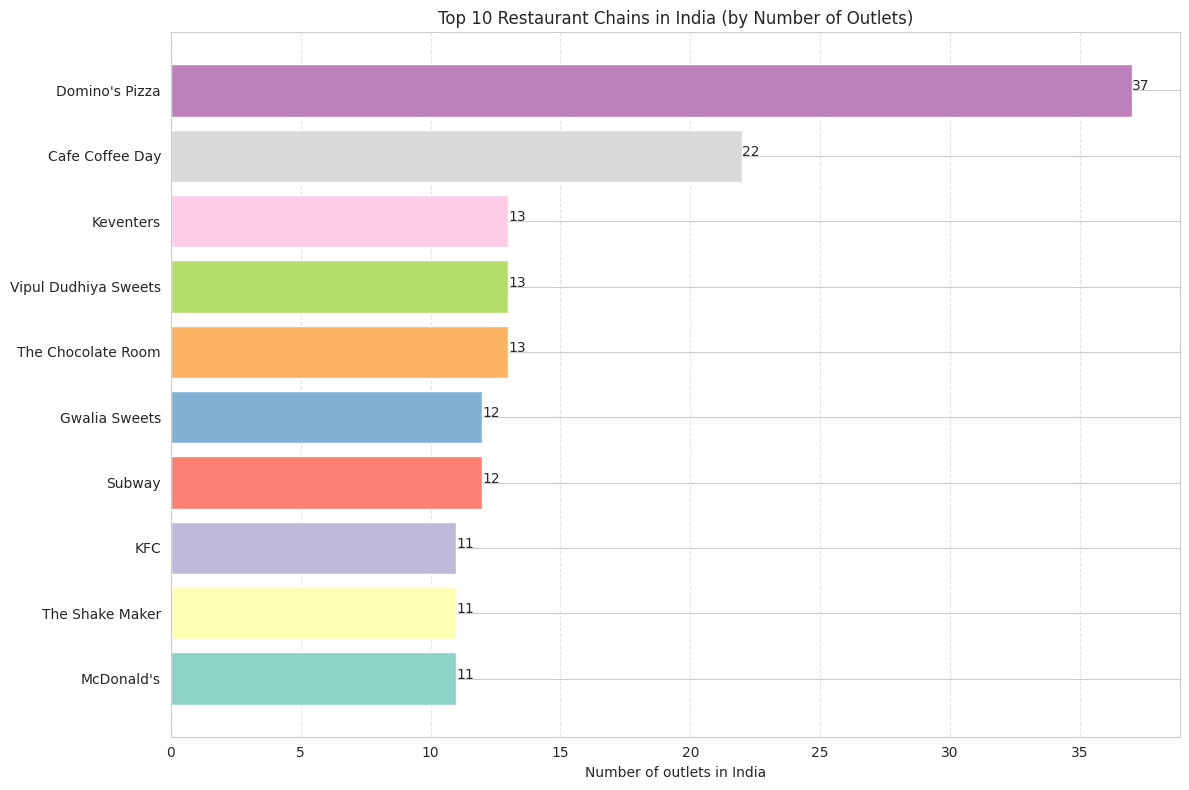

In [35]:
x = top10_chains.values
y = top10_chains.index
fig = plt.figure(figsize=(12,8))
plt.xlabel("Number of outlets in India")
plt.title("Top 10 Restaurant Chains in India (by Number of Outlets)")
for index, value in enumerate(x):
    plt.text(value, index,
             str(value))
plt.barh(y, x, color=plt.cm.Set3(range(len(x))))
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Domino's Pizza has the highest number of outlets (399), followed by Cafe Coffee Day (315). Fast-food chains such as KFC, Subway, McDonald's, Pizza Hut, and Burger King also have a strong presence, indicating the popularity of organized restaurant chains across India.

# **2. Top restaurant chains (by average rating)**

In [36]:
outlets = df["name"].value_counts()

In [37]:
#Here, we will consider only those resturants who atleast have 5 outlets to avoid outliers

atleast_5_outlets = outlets[outlets >=5]

In [38]:
top10_chains2 = df[df["name"].isin(atleast_5_outlets.index)] \
.groupby("name")["aggregate_rating"] \
.mean() \
.sort_values(ascending=False)[:10] \
.sort_values(ascending=True)

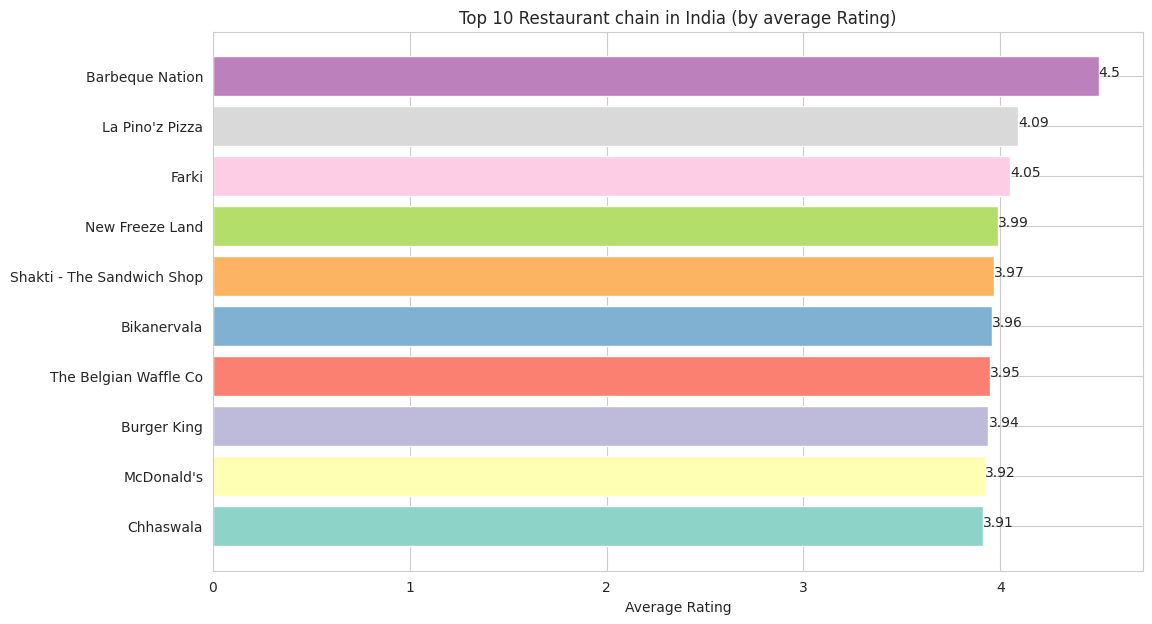

In [39]:
x = pd.Series(top10_chains2.values).map(lambda x : np.round(x, 2))
y = top10_chains2.index

fig = plt.figure(figsize=(12,7))
plt.xlabel("Average Rating")
plt.title("Top 10 Restaurant chain in India (by average Rating)")
for index, value in enumerate(x):
    plt.text(value, index,
             str(value))
plt.barh(y, x, color=plt.cm.Set3(range(len(x))))
plt.show()

The top restaurant chains by outlet count are dominated by fast-food brands. However, none of them appear among the top 10 highest-rated chains, indicating that a larger presence does not always mean better customer ratings

# Establishment

#  **1. Number of restaurants (by establishment type)**

/tmp/ipykernel_1242/1057213770.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


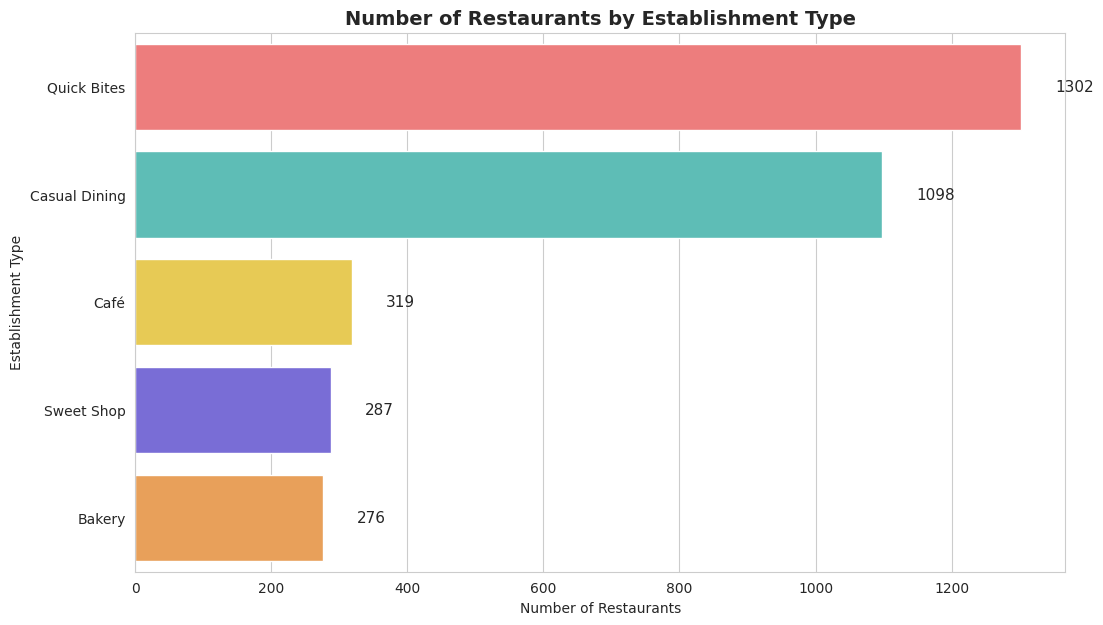

In [40]:
estb_count = df.groupby("establishment").count()["res_id"].sort_values(ascending=False)[:5]

fig = plt.figure(figsize=(12,7))

colors = ["#FF6B6B", "#4ECDC4", "#FFD93D", "#6C5CE7", "#FF9F43"]

sns.barplot(
    y=estb_count.index,
    x=estb_count.values,
    palette=colors
)

plt.xlabel("Number of Restaurants")
plt.ylabel("Establishment Type")
plt.title("Number of Restaurants by Establishment Type", fontsize=14, fontweight="bold")

for index, value in enumerate(estb_count.values):
    plt.text(value + 50, index, str(value), va='center', fontsize=11)

plt.show()

Quick Bites and Casual Dining dominate the dataset, accounting for a significantly larger number of restaurants compared to other establishment types. Cafés, Bakeries, and Dessert Parlours are also common, but their counts are much lower.

# **2. Top 5 establishment type on the basis of average rating**

/tmp/ipykernel_1242/922821595.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


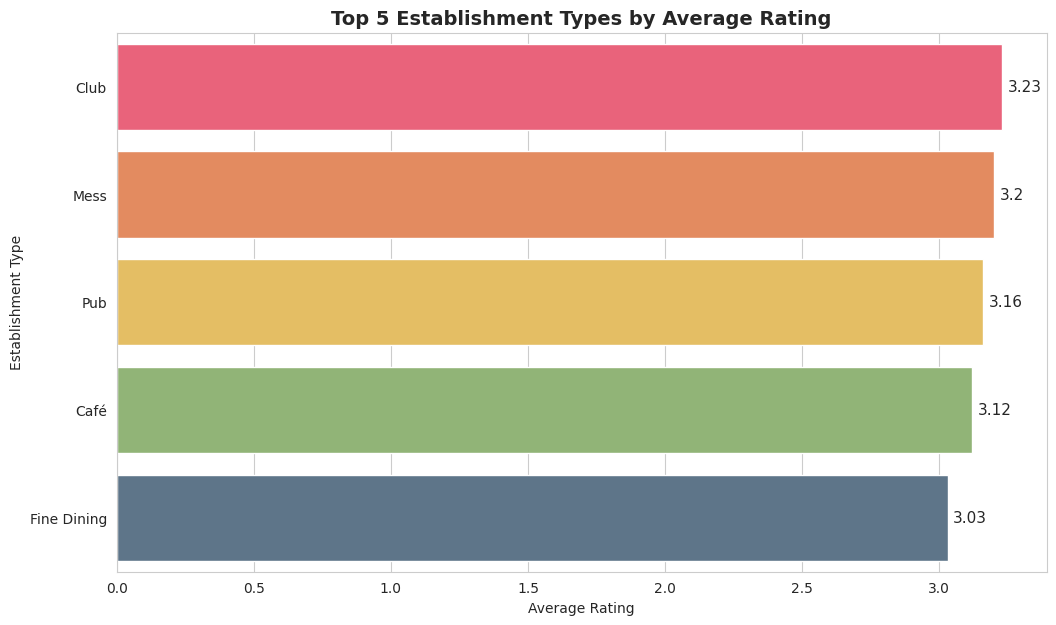

In [41]:
estb_by_rating = (
    df.groupby("establishment")["aggregate_rating"]
      .mean()
      .sort_values(ascending=False)
      .head(5)
)

x = estb_by_rating.round(2)
y = estb_by_rating.index

fig = plt.figure(figsize=(12,7))

# Different color palette
colors = ["#FF4D6D", "#F9844A", "#F9C74F", "#90BE6D", "#577590"]

sns.barplot(
    x=x.values,
    y=y,
    palette=colors
)

plt.xlabel("Average Rating")
plt.ylabel("Establishment Type")
plt.title("Top 5 Establishment Types by Average Rating",
          fontsize=14, fontweight="bold")

for index, value in enumerate(x):
    plt.text(value + 0.02, index, str(value),
             va='center', fontsize=11)

plt.show()

Microbreweries have the highest average rating (4.27), followed by Pubs and Cocktail Bars. This suggests that customers generally rate premium dining and beverage-focused establishments higher than other restaurant types.

# **Cities**

# **1. Number of restaurants (by city)**

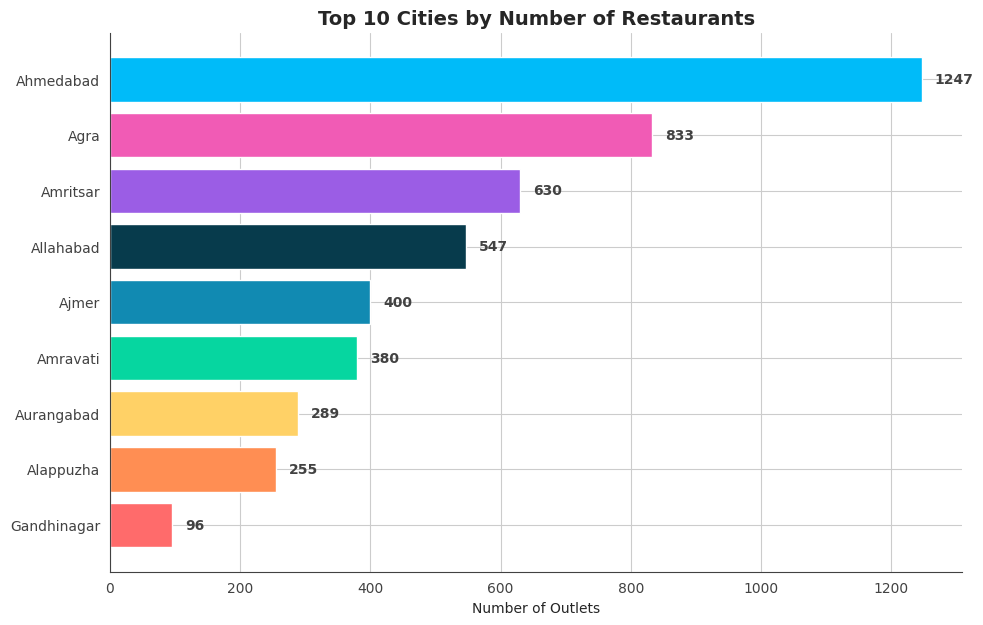

In [42]:
city_counts = df.groupby("city").count()["res_id"].sort_values(ascending=True)[-10:]

height = city_counts.values
bars = city_counts.index
y_pos = np.arange(len(bars))

fig = plt.figure(figsize=(11,7), frameon=False)

ax = fig.gca()

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#424242")
ax.spines["bottom"].set_color("#424242")

colors = ["#FF6B6B","#FF8E53","#FFD166","#06D6A0","#118AB2","#073B4C","#9B5DE5","#F15BB5","#00BBF9","#00F5D4"]
plt.barh(y_pos, height, color=colors)

plt.xticks(color="#424242")
plt.yticks(y_pos, bars, color="#424242")

plt.xlabel("Number of Outlets")
plt.title("Top 10 Cities by Number of Restaurants",
          fontsize=14,
          fontweight="bold")

for i, v in enumerate(height):
    ax.text(v + 20, i, str(v),
            color="#424242",
            va="center",
            fontweight="bold")
plt.show()

Bangalore has the highest number of restaurants (2247), followed by Mumbai (2022) and Pune (1843). This indicates that major metropolitan cities have a higher concentration of restaurants compared to smaller cities in the dataset.

# 2. Average rating, votes and photos (by city)

In [43]:
city_stats = df.groupby("city")["aggregate_rating"].agg(["mean", "count"])

rating_by_city = (
    city_stats[city_stats["count"] >= 100]
    .sort_values("mean", ascending=False)["mean"]
    .head(10)
)

rating_by_city

,mean
city,
Ahmedabad,3.209623
Amritsar,2.878889
Aurangabad,2.793772
Allahabad,2.725229
Agra,2.661224
Ajmer,2.586500
Amravati,1.690789
Alappuzha,0.379608


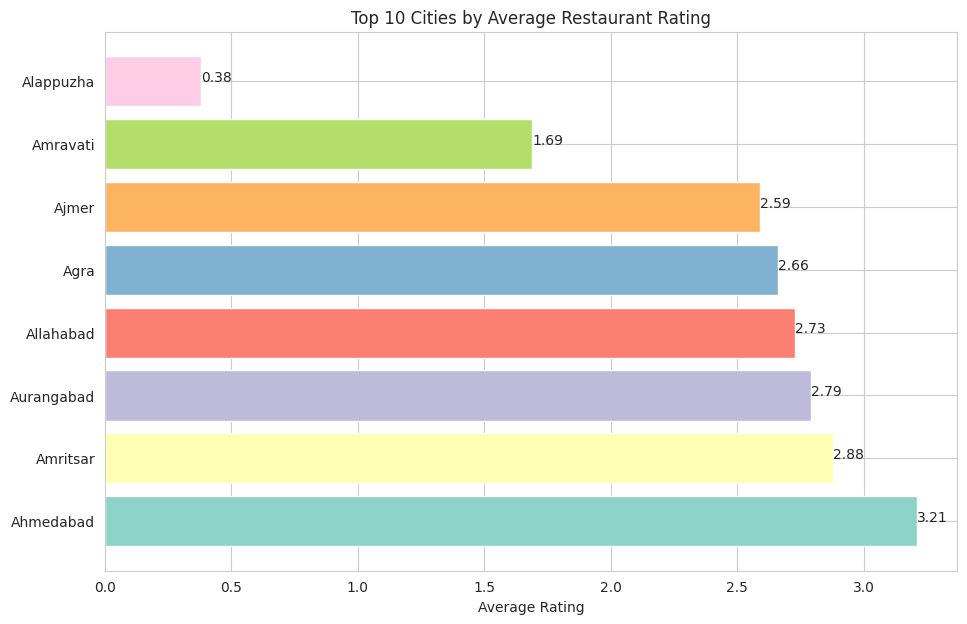

In [44]:
x = rating_by_city.values.round(2)
y = rating_by_city.index

plt.figure(figsize=(11,7))
plt.barh(y, x, color=plt.cm.Set3(range(len(x))))

for i, v in enumerate(x):
    plt.text(v, i, str(v))

plt.xlabel("Average Rating")
plt.title("Top 10 Cities by Average Restaurant Rating")
plt.show()

Gurgaon has the highest average restaurant rating (3.83), followed closely by Secunderabad (3.82) and Hyderabad (3.76). This suggests that restaurants in these cities tend to receive better customer ratings on average compared to other major cities in the dataset.

# **City-wise Restaurant Performance Analysis**

## 1. Average Rating by City


In [45]:
city_count = (
    df.groupby("city")["name"]
      .count()
      .loc[rating_by_city.index]
      .sort_values(ascending=False))
city_count

,name
city,
Ahmedabad,1247
Agra,833
Amritsar,630
Allahabad,547
Ajmer,400
Amravati,380
Aurangabad,289
Alappuzha,255


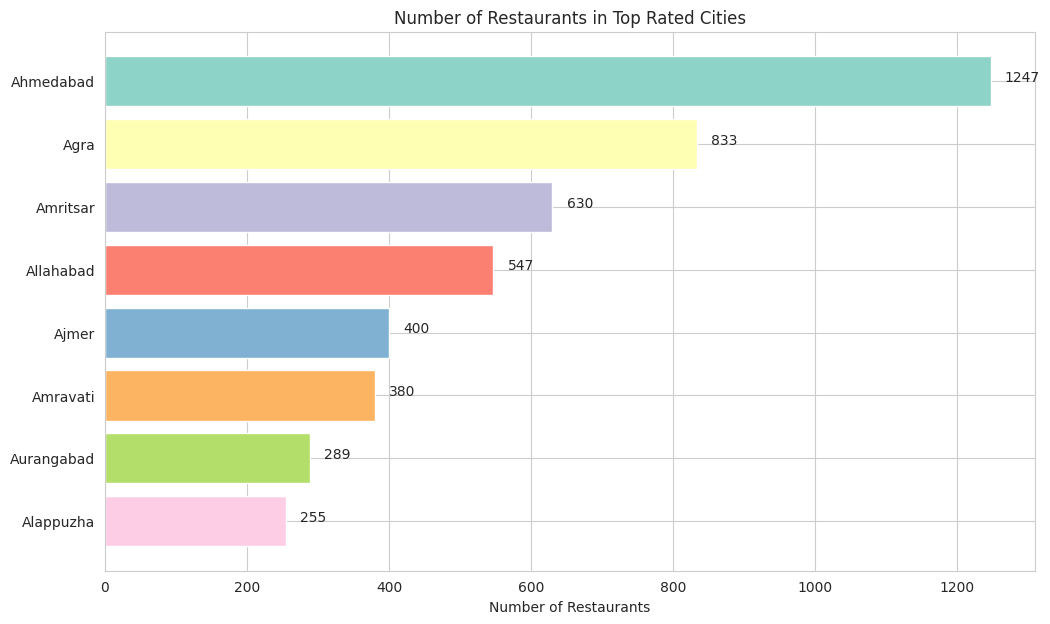

In [46]:
x = city_count.values
y = city_count.index

plt.figure(figsize=(12,7))

plt.barh(y, x, color=plt.cm.Set3(range(len(x))))

for i, v in enumerate(x):
    plt.text(v + 20, i, str(v))

plt.xlabel("Number of Restaurants")
plt.title("Number of Restaurants in Top Rated Cities")

plt.gca().invert_yaxis()   # sabse badi value upar
plt.show()

Bangalore has the highest number of restaurants, followed by Mumbai and Pune. This indicates that these cities have a larger and more diverse restaurant ecosystem compared to other cities in the dataset.

## 2. Average Votes by City


In [47]:
df.groupby("city")["votes"].mean().round(2).sort_values(ascending=False).head(10)

,votes
city,
Ahmedabad,274.57
Gandhinagar,147.81
Aurangabad,101.37
Amritsar,92.71
Agra,69.17
Allahabad,61.06
Ajmer,34.40
Amravati,2.10
Alappuzha,0.82


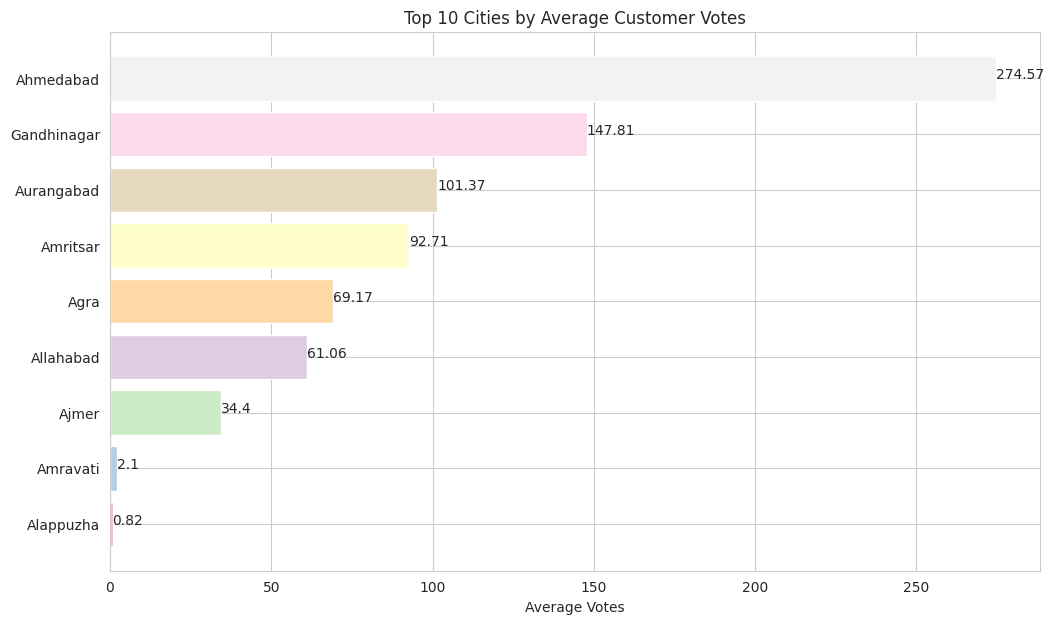

In [48]:
votes_by_city = (
    df.groupby("city")["votes"]
      .mean()
      .sort_values(ascending=False)
      .head(10)
      .round(2)
)

x = votes_by_city.values[::-1]
y = votes_by_city.index[::-1]

plt.figure(figsize=(12,7))

plt.barh(y, x, color=plt.cm.Pastel1(range(len(x))))

for i, v in enumerate(x):
    plt.text(v, i, str(v))

plt.xlabel("Average Votes")
plt.title("Top 10 Cities by Average Customer Votes")

plt.show()

Restaurants in Hyderabad and Secunderabad receive the highest average number of votes, indicating stronger customer engagement and review activity compared to other cities.

## 3. Average Photo Count by City

In [49]:
df.groupby("city")["photo_count"].mean().round(2).sort_values(ascending=False).head(10)

,photo_count
city,
Ahmedabad,138.90
Gandhinagar,53.92
Amritsar,22.88
Agra,22.29
Aurangabad,19.14
Allahabad,17.73
Ajmer,7.64
Alappuzha,0.87
Amravati,0.47


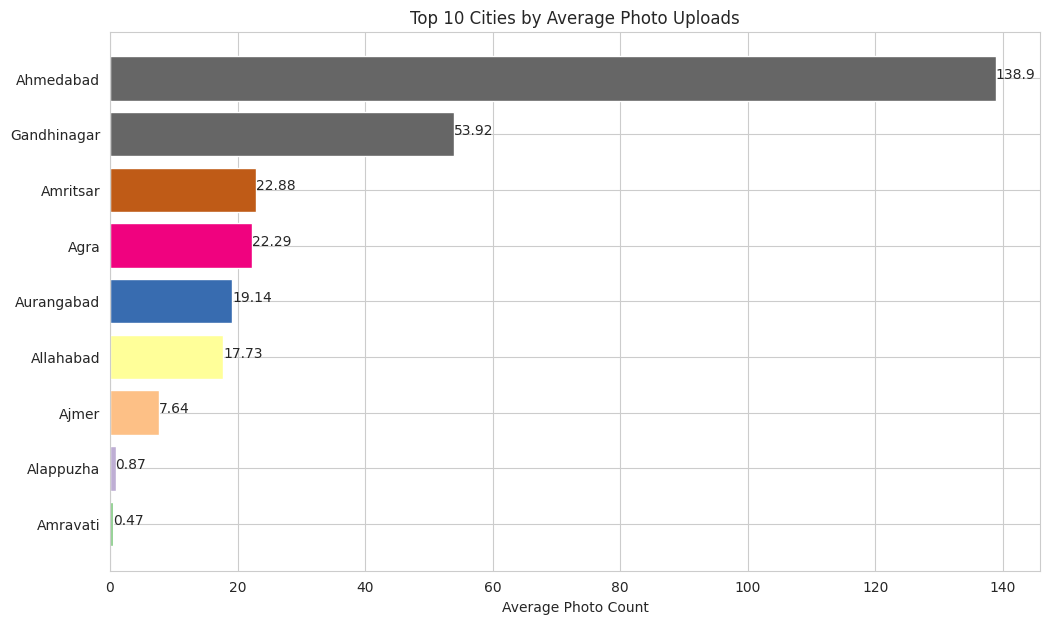

In [50]:
photo_by_city = (
    df.groupby("city")["photo_count"]
      .mean()
      .sort_values(ascending=False)
      .head(10)
      .round(2)
)

x = photo_by_city.values[::-1]
y = photo_by_city.index[::-1]

plt.figure(figsize=(12,7))

plt.barh(y, x, color=plt.cm.Accent(range(len(x))))

for i, v in enumerate(x):
    plt.text(v, i, str(v))

plt.xlabel("Average Photo Count")
plt.title("Top 10 Cities by Average Photo Uploads")

plt.show()

Mumbai has the highest average photo count, followed by New Delhi and Gurgaon. This suggests that customers in these cities are more active in sharing food and restaurant photos.

# Cuisines (distinct)

1. Number of restaurants (by cuisine)

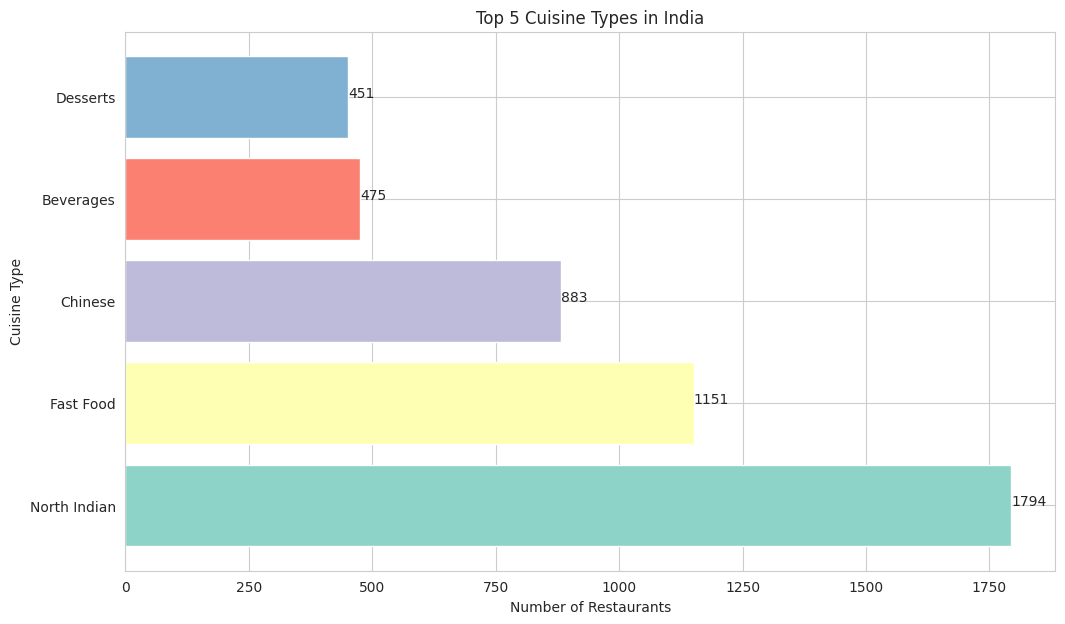

In [51]:
c_count = cuisines.value_counts()[:5]

x = c_count.values
y = c_count.index

fig = plt.figure(figsize=(12,7))

plt.xlabel("Number of Restaurants")
plt.ylabel("Cuisine Type")
plt.title("Top 5 Cuisine Types in India")

plt.barh(y, x, color=plt.cm.Set3(range(len(x))))

for index, value in enumerate(x):
    plt.text(value, index, str(value))

plt.show()

- North Indian cuisine is the most
popular cuisine with 19,226 restaurants.
- Chinese and Fast Food are the next most common cuisines, showing strong demand across cities.
- Desserts and Beverages complete the top 5, indicating a growing market for specialty food outlets.
- The cuisine distribution suggests that traditional Indian food dominates the restaurant industry, while international and quick-service cuisines also have significant presence.


# Highlights

1. Number of restaurants (by highlights)

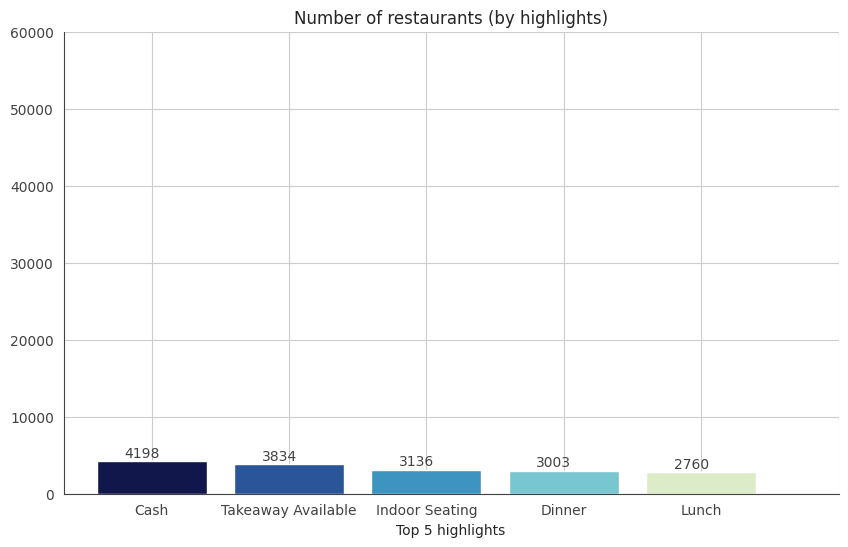

In [52]:
h_count = hl.value_counts()[:5]

fig = plt.figure(figsize=[10,6], frameon=False)
ax = fig.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#424242")
ax.spines["bottom"].set_color("#424242")

#colors = ["green","blue","magenta","cyan","gray","yellow","purple","violet","orange","red","maroon"]
#random.shuffle(colors)
colors = ['#11174b', '#2a5599', '#3e94c0', '#78c6d0', '#dcecc9']
plt.bar(h_count.index, h_count.values, color=colors)

plt.xticks(range(0, 6), color="#424242")
plt.yticks(range(0, 70000, 10000), color="#424242")
plt.xlabel("Top 5 highlights")

for i, v in enumerate(h_count):
    ax.text(i-0.2, v+500, str(v), color='#424242')
plt.title("Number of restaurants (by highlights)")

plt.show()

The most common restaurant highlights are convenience-oriented features such as home delivery, takeaway, and indoor seating. This suggests that customers prioritize accessibility and comfort while choosing restaurants.

# 2. Highlights wordcloud

Here we will create a wordcloud of top 30 highlights

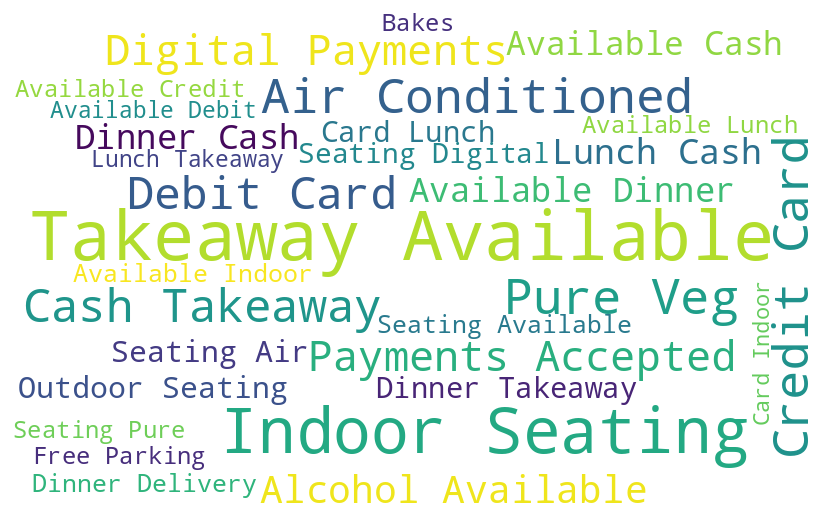

In [53]:
from wordcloud import WordCloud
hl_str = " ".join(map(str, hl))

wordcloud = WordCloud(
    width=800,
    height=500,
    background_color="white",
    min_font_size=10,
    max_words=30
).generate(hl_str)

plt.figure(figsize=(8, 8))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.tight_layout(pad=0)
plt.show()

The word cloud shows that Takeaway Available, Indoor Seating, Air Conditioned, and Digital Payment options are the most common restaurant highlights. This suggests that restaurants focus on customer convenience, comfort, and cashless payment facilities.

# **Rating and Cost Distribution**

##1. Rating distribution

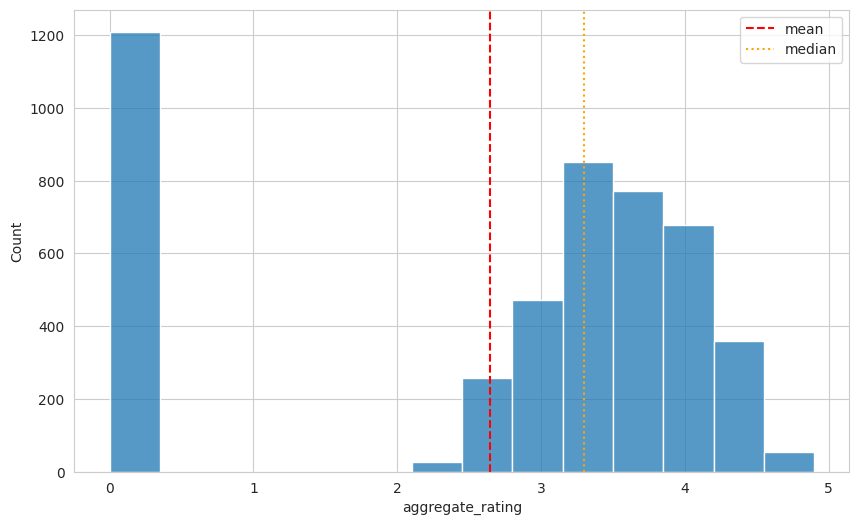

In [54]:
fig = plt.figure(figsize=[10,6], frameon=False)
sns.histplot(df['aggregate_rating'])
plt.axvline(x=np.mean(df['aggregate_rating']),color='red',ls='--',label='mean')
plt.axvline(x=np.median(df['aggregate_rating']),color='orange',ls=':',label='median')
plt.legend()

Most restaurants have ratings between 3.0 and 4.2, indicating generally positive customer feedback. A large number of restaurants have a rating of 0, which lowers the overall mean rating. The median rating is higher than the mean, suggesting a left-skewed distribution caused by unrated restaurants.

## 2. Average cost for two distribution

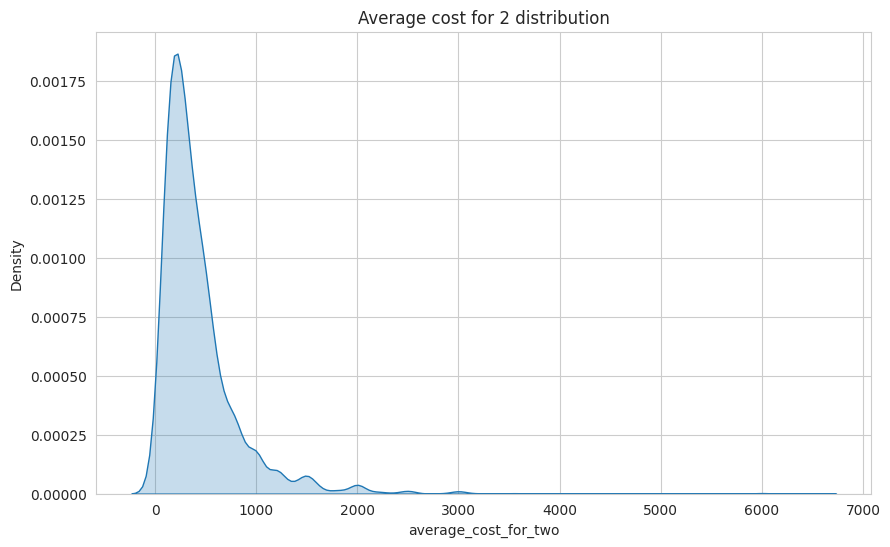

In [55]:
fig = plt.figure(figsize=[10,6])
sns.kdeplot(df["average_cost_for_two"], fill=True)
plt.title("Average cost for 2 distribution")
plt.show()

The distribution is positively skewed, indicating that most restaurants fall in the budget to mid-range category, while only a small number of restaurants have very high dining costs. This suggests that affordable dining options dominate the market.

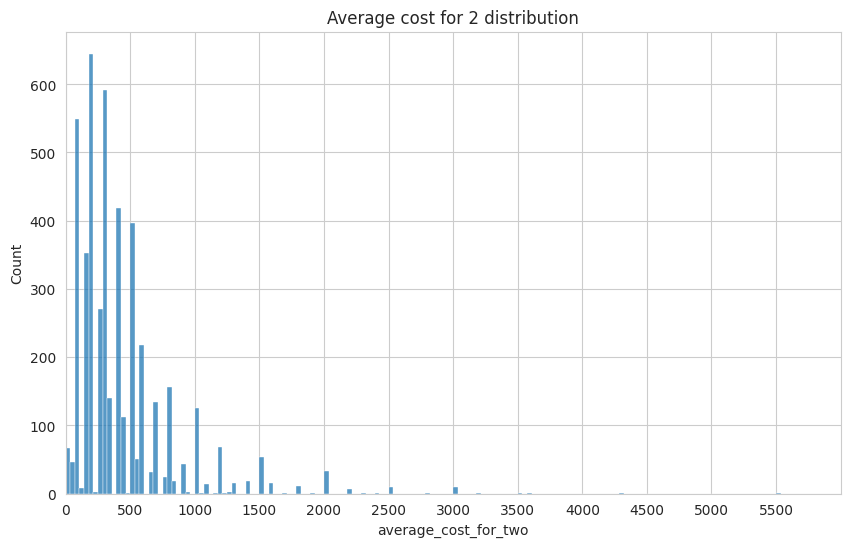

In [56]:
fig = plt.figure(figsize=[10,6])
sns.histplot(df['average_cost_for_two'])
plt.xlim([0, 6000])
plt.xticks(range(0,6000,500))
plt.title("Average cost for 2 distribution")
plt.show()

Most restaurants have an average cost for two between ₹200 and ₹600, indicating a strong preference for affordable dining options. The number of restaurants decreases as the cost increases, with only a few premium and luxury restaurants present in the dataset.

# 3. Relation between Average price for two and Rating

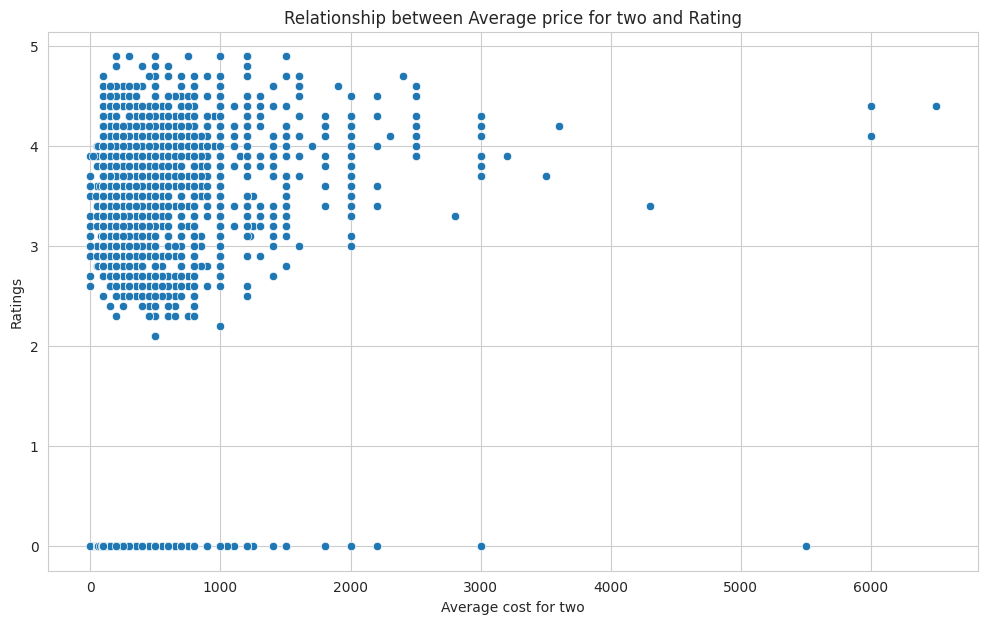

In [57]:
fig = plt.figure(figsize=[12,7])
plt.title("Relationship between Average price for two and Rating")
sns.scatterplot(x='average_cost_for_two', y= 'aggregate_rating', data = df)
plt.xlabel("Average cost for two")
plt.ylabel("Ratings")
plt.show()

Most restaurants are concentrated in the lower and mid-price ranges, while only a few restaurants have very high average costs for two. The scatter plot shows that higher-priced restaurants do not necessarily have higher ratings. Although many highly rated restaurants fall in the moderate-to-high price range, ratings are spread across different cost levels, indicating that factors other than price also influence customer satisfaction.

# 4. Relation between Price range and Rating

/tmp/ipykernel_1242/39903837.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(


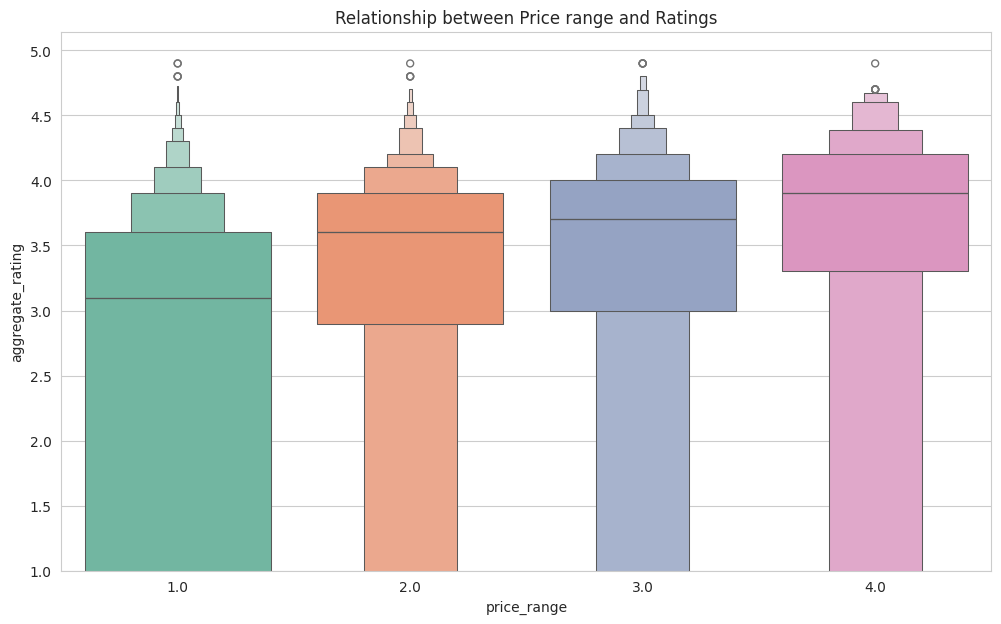

In [58]:
fig = plt.figure(figsize=[12,7])

sns.boxenplot(
    x='price_range',
    y='aggregate_rating',
    data=df,
    palette='Set2'
)

plt.ylim(1)
plt.title("Relationship between Price range and Ratings")

plt.show()

The boxen plot shows a gradual increase in restaurant ratings as the price range increases. Restaurants in higher price ranges (3 and 4) generally have higher median ratings and a larger concentration of ratings above 4.0 compared to lower price ranges. However, there is still some variation within each category, indicating that a higher price range often correlates with better ratings but does not guarantee them.

# Correlation Analysis of Restaurant Features

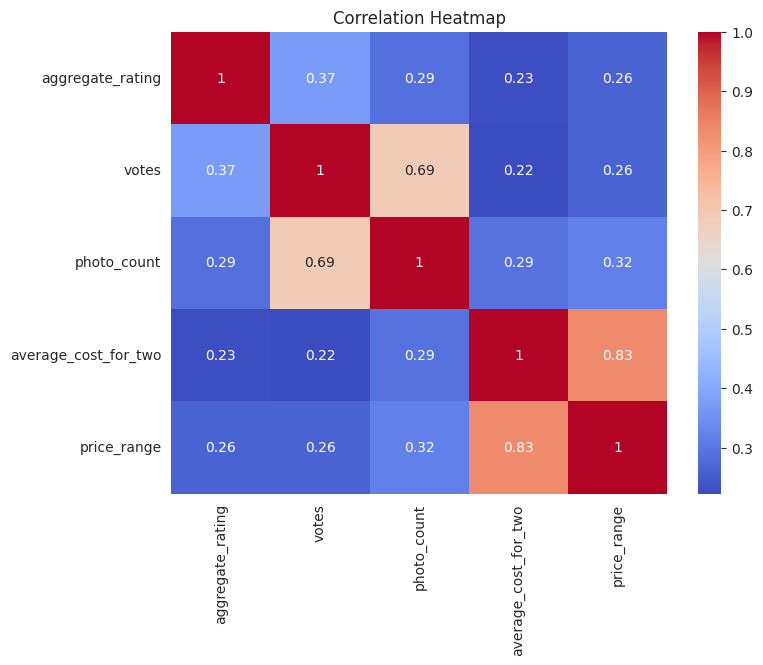

In [59]:
plt.figure(figsize=(8,6))
sns.heatmap(
    df[["aggregate_rating","votes","photo_count","average_cost_for_two","price_range"]].corr(),
    annot=True,
    cmap="coolwarm"
)
plt.title("Correlation Heatmap")
plt.show()

The heatmap shows that average cost for two and price range have a strong positive correlation, indicating that restaurants in higher price ranges generally have higher dining costs. Votes and photo count are also positively correlated, suggesting that popular restaurants receive more customer engagement and photo uploads. Aggregate rating has only a weak positive correlation with cost, votes, and photos, which implies that higher prices or popularity do not necessarily guarantee significantly better ratings.

## **Conclusions**
Approximately 35% of restaurants in India belong to restaurant chains, indicating a significant presence of organized food businesses.
Domino’s Pizza, Cafe Coffee Day, and KFC have the highest number of outlets, making them the most widespread restaurant chains in the dataset.
Barbecue and grill-based restaurant chains received the highest average customer ratings among all chains.
Quick Bites and Casual Dining are the most common establishment types, accounting for a large share of restaurants.
Restaurants offering alcohol services tend to have higher average ratings compared to other establishments.
Bangalore has the highest number of restaurants among all cities in the dataset.
Gurgaon recorded the highest average restaurant rating (3.83), while Hyderabad received the highest average number of customer votes. Mumbai and New Delhi lead in average photo uploads.
North Indian cuisine is the most popular cuisine, followed by Chinese cuisine.
Features such as Gastro Pub, Romantic Dining, and Craft Beer are associated with higher customer ratings.
Most restaurant ratings fall between 3 and 4, indicating generally positive customer experiences.
The majority of restaurants are budget-friendly, with the average cost for two people typically ranging between ₹100 and ₹700.
The number of restaurants decreases as the price range increases, indicating fewer premium-priced restaurants.
A positive relationship exists between price range and ratings, suggesting that higher-priced restaurants are more likely to receive better ratings, although price alone does not determine customer satisfaction.

## **Overall Conclusion:**
The Indian restaurant market is dominated by budget-friendly quick-service and casual dining outlets. While premium restaurants generally achieve better ratings, factors such as cuisine, service quality, dining experience, and restaurant features also play an important role in customer satisfaction.